In [123]:
import utils
import numpy as np
import pandas as pd
import os
import importlib
import glob
import re
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', None)

# Exclusion criteria
- Check only the last two blocks
- cutoff for congruent = 60%
- cutoff for incongruent = 100% - congruent + 10%

In [124]:
# Preparation
unique_subject_ids = [12]#[802,803,804,805,806,807,808,809,810,811,813,814,815]
unique_sessions = [1]
plot_range = [0, 6]
raw_output_path = '/Volumes/project/3025011.02/raw/'

recent_results = utils.analysis_functions.list_files_with_date_and_subject_id(raw_output_path, unique_subject_ids, unique_sessions)

In [125]:
combined_results_dataframe = utils.analysis_functions.combine_result_files(recent_results)
unique_subject_ids = combined_results_dataframe['subject_id'].unique()
unique_sessions = combined_results_dataframe['session'].unique()
print(combined_results_dataframe)

     trial  emotional_cue_time response objectively_correct  \
0        0        1.741961e+09       up                Even   
1        1        1.741961e+09     down                Even   
2        2        1.741961e+09       up                Even   
3        3        1.741961e+09     down                Even   
4        4        1.741961e+09       up                Even   
5        5        1.741961e+09     down                Even   
6        6        1.741961e+09     down                Even   
7        7        1.741961e+09       up                Even   
8        8        1.741961e+09       up                True   
9        9        1.741961e+09     down                True   
10      10        1.741961e+09       up               False   
11      11        1.741961e+09     down               False   
12      12        1.741961e+09       up                True   
13      13        1.741961e+09     down               False   
14      14        1.741961e+09       up               F

# Add congruency, volatility etc

In [126]:
combined_results_dataframe['congruency'] = combined_results_dataframe.apply(utils.analysis_functions.check_congruency, axis=1)
print(combined_results_dataframe[['stimuli_type','probability_condition','congruency']])

     stimuli_type  probability_condition   congruency
0               2                     50    undefined
1               1                     50    undefined
2               2                     50    undefined
3               1                     50    undefined
4               2                     50    undefined
5               1                     50    undefined
6               2                     50    undefined
7               1                     50    undefined
8               1                     80    congruent
9               2                     20    congruent
10              2                     20    congruent
11              1                     80    congruent
12              1                     80    congruent
13              1                     80    congruent
14              2                     20    congruent
15              1                     80    congruent
16              2                     20    congruent
17              2           

In [127]:
combined_results_dataframe = combined_results_dataframe[combined_results_dataframe['probability_condition'] != 50]
combined_results_dataframe = utils.analysis_functions.check_volatility(combined_results_dataframe)
dataframe_volatility_check = combined_results_dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])
print(dataframe_volatility_check[['trial','stimuli_type','probability_condition','volatility']])

     trial  stimuli_type  probability_condition volatility
0        8             1                     80   volatile
3       11             1                     80   volatile
4       12             1                     80   volatile
5       13             1                     80   volatile
7       15             1                     80   volatile
10      18             1                     80   volatile
11      19             1                     80     stable
14      22             1                     80     stable
17      25             1                     80     stable
20      28             1                     80     stable
21      29             1                     80     stable
22      30             1                     80     stable
23      31             1                     80     stable
26      34             1                     80     stable
28      36             1                     80     stable
29      37             1                     80     stab

In [128]:
combined_results_dataframe['valence'] = combined_results_dataframe.apply(utils.analysis_functions.check_valence, axis=1)
print(combined_results_dataframe[['stimuli_type','valence']])

     stimuli_type valence
0               1   angry
1               2   happy
2               2   happy
3               1   angry
4               1   angry
5               1   angry
6               2   happy
7               1   angry
8               2   happy
9               2   happy
10              1   angry
11              1   angry
12              2   happy
13              2   happy
14              1   angry
15              2   happy
16              2   happy
17              1   angry
18              2   happy
19              2   happy
20              1   angry
21              1   angry
22              1   angry
23              1   angry
24              2   happy
25              2   happy
26              1   angry
27              2   happy
28              1   angry
29              1   angry
30              1   angry
31              2   happy
32              2   happy
33              2   happy
34              2   happy
35              1   angry
36              2   happy
37          

In [129]:
# Turns the objective values into boolean ones
mapping = {'True': 1, 'False': 0, 'Even': 0, 'Late': 0}
#pd.options.display.max_rows = None

combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct'].replace(mapping)
combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct_boolean'].astype('int')
print(combined_results_dataframe)

     trial  emotional_cue_time response objectively_correct  \
0        8        1.741961e+09       up                True   
1        9        1.741961e+09     down                True   
2       10        1.741961e+09       up               False   
3       11        1.741961e+09     down               False   
4       12        1.741961e+09       up                True   
5       13        1.741961e+09     down               False   
6       14        1.741961e+09       up               False   
7       15        1.741961e+09     down               False   
8       16        1.741961e+09     down                True   
9       17        1.741961e+09       up               False   
10      18        1.741961e+09     down               False   
11      19        1.741961e+09     down               False   
12      20        1.741961e+09       up               False   
13      21        1.741961e+09       up               False   
14      22        1.741961e+09     down               F

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5975/872166504.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct'].replace(mapping)


# Remove everything but the last two blocks

In [130]:
# Create a helper column that increments whenever the value changes.
# This assigns a unique group number to each contiguous block.
last_blocks_results = combined_results_dataframe
last_blocks_results['group'] = (last_blocks_results['volatility'] != last_blocks_results['volatility'].shift()).cumsum()
print(last_blocks_results[['subject_id','session','stimuli_type','volatility','group']])

# For each type ('stable' and 'volatile'), find the maximum group number (the last block)
last_stable_group = last_blocks_results.loc[last_blocks_results['volatility'] == 'stable', 'group'].max()
last_volatile_group = last_blocks_results.loc[last_blocks_results['volatility'] == 'volatile', 'group'].max()

# Filter to keep only rows that belong to these last blocks
last_blocks_results = last_blocks_results[last_blocks_results['group'].isin([last_stable_group, last_volatile_group])].copy()

    subject_id     session  stimuli_type volatility  group
0      sub-012  session-01             1   volatile      1
1      sub-012  session-01             2   volatile      1
2      sub-012  session-01             2   volatile      1
3      sub-012  session-01             1   volatile      1
4      sub-012  session-01             1   volatile      1
5      sub-012  session-01             1   volatile      1
6      sub-012  session-01             2   volatile      1
7      sub-012  session-01             1   volatile      1
8      sub-012  session-01             2   volatile      1
9      sub-012  session-01             2   volatile      1
10     sub-012  session-01             1   volatile      1
11     sub-012  session-01             1     stable      2
12     sub-012  session-01             2   volatile      3
13     sub-012  session-01             2     stable      4
14     sub-012  session-01             1     stable      4
15     sub-012  session-01             2     stable     

In [131]:
# Optionally, remove the helper column
last_blocks_results.drop(columns='group', inplace=True)

dataframe_block_removal_check = last_blocks_results.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])
print(dataframe_block_removal_check[['stimuli_type','congruency','volatility']])

     stimuli_type   congruency volatility
440             1    congruent     stable
443             1    congruent     stable
445             1    congruent     stable
446             1    congruent     stable
450             1    congruent     stable
452             1    congruent     stable
453             1    congruent     stable
454             1    congruent     stable
458             1    congruent     stable
459             1    congruent     stable
461             1    congruent     stable
464             1    congruent     stable
465             1    congruent     stable
468             1    congruent     stable
469             1    congruent     stable
470             1    congruent     stable
474             1    congruent     stable
475             1    congruent     stable
477             1    congruent     stable
478             1    congruent     stable
479             1    congruent     stable
480             1    congruent     stable
484             1    congruent    

In [132]:
# Create new plots with different intervals that also contain the 50% trials
unique_stimuli_types = last_blocks_results['stimuli_type'].unique()
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'congruency', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6}
group_name = 'congruency'
session_name = 'session'
unique_group_types = last_blocks_results[group_name].unique()


all_switches_dataframe = utils.analysis_functions.find_switches_in_dataframe(last_blocks_results,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, plot_range, mapping, session_name)
print(all_switches_dataframe)

    subject_id  trial  stimuli_type  probability_condition switch  \
440    sub-012    448             1                     80  False   
443    sub-012    451             1                     80  False   
445    sub-012    453             1                     80  False   
446    sub-012    454             1                     80  False   
450    sub-012    458             1                     80  False   
452    sub-012    460             1                     80  False   
453    sub-012    461             1                     80  False   
454    sub-012    462             1                     80  False   
458    sub-012    466             1                     80  False   
459    sub-012    467             1                     80  False   
461    sub-012    469             1                     80  False   
464    sub-012    472             1                     80  False   
465    sub-012    473             1                     80  False   
468    sub-012    476             

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:568: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  input_dataframe['switch'].iloc[0] = 'False'
/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_fun

Mean score for the congruent condition 31.25% is below the 60% threshold.
Exclude the participant.



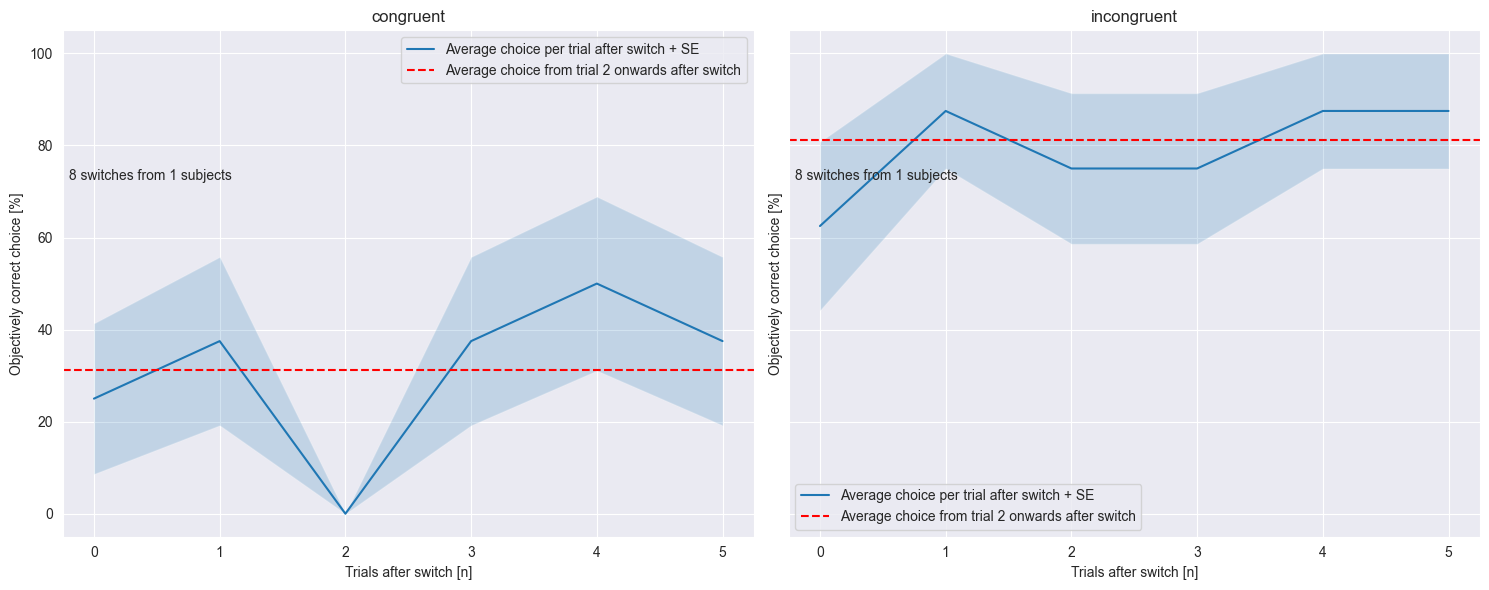

In [138]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_switches_dataframe.set_index('congruency')

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])
df = df.drop(columns=['session'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('congruency').mean()
means = means*100
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()
stds = df.groupby('congruency').sem()
stds = stds * 100

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

#fig.suptitle('Objective performance grouped for congruency', fontsize=24, y=0.982)

congruency_list = all_switches_dataframe['congruency'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    if congruency_type != 'undefined':
        # Timepoints are the column names converted to integers for x-axis values
        timepoints = list(range(plot_range[0], plot_range[1]))
        mean_values = means.loc[congruency_type]
        std_values = stds.loc[congruency_type]

        axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
        axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
        axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
        #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
        axs[i].set_title(congruency_type)
        axs[i].set_xlabel('Trials after switch [n]')
        axs[i].set_ylabel('Objectively correct choice [%]')
        axs[i].text(-0.2, 72.5, f'{group_counts[congruency_type]} switches from {subject_counts} subjects', fontsize=10)
        axs[i].legend()
        axs[i].grid(True)

plt.tight_layout()
if average_choice_after_switch_total[0] < 60:
    print(f'Mean score for the congruent condition {average_choice_after_switch_total[0]}% is below the 60% threshold.\n'
          'Exclude the participant.\n')
elif average_choice_after_switch_total[1] < 40:
    print(f'Mean score for the incongruent condition {average_choice_after_switch_total[1]}% is below the 40% threshold.\n'
          'Exclude the participant.\n')
elif (1 - average_choice_after_switch_total[0] + 10) > average_choice_after_switch_total[1]:
    print(f'Mean score for the incongruent condition {average_choice_after_switch_total[1]}% is below the threshold 1 - congruent score + 10 {(1 - average_choice_after_switch_total[0] + 10)}%\n'
          'Exclude the participant.\n')
plt.show()

# Reaction time check

12 out of 660 trials are non-response trials
So, 1.82% of the trials are non-response trials



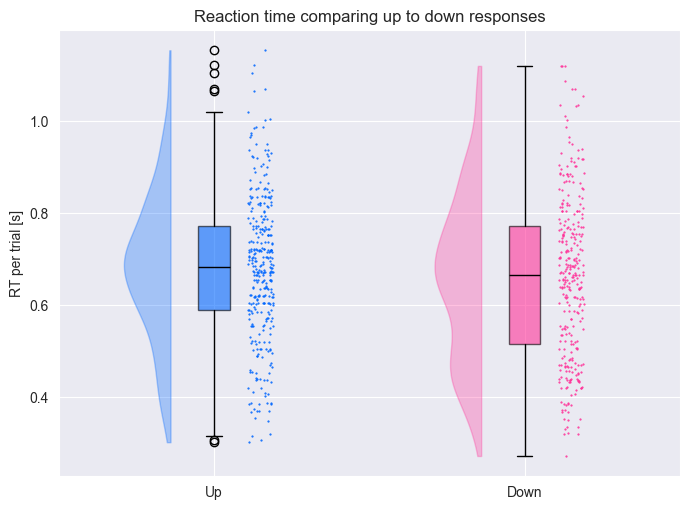

In [134]:
# Print percentage of non-response trials
non_response_trials = combined_results_dataframe[combined_results_dataframe['response'].isna()]
percentage_responses = len(non_response_trials)/len(combined_results_dataframe)*100

if percentage_responses > 10:
    print(f'{len(non_response_trials)} out of {len(combined_results_dataframe)} trials are non-response trials\n'
      f'So, {percentage_responses:.2f}% of the trials are non-response trials\n'
      'This means that the participant responded in less than 90% of the trials.\n'
          'Exclude the participant.\n')
else:
    print(f'{len(non_response_trials)} out of {len(combined_results_dataframe)} trials are non-response trials\n'
      f'So, {percentage_responses:.2f}% of the trials are non-response trials\n')

# Plot reaction time
happy_dataframe = combined_results_dataframe[combined_results_dataframe['response'] == 'up']
happy_list = happy_dataframe['RT_s'].dropna().tolist()
angry_dataframe = combined_results_dataframe[combined_results_dataframe['response'] == 'down']
angry_list = angry_dataframe['RT_s'].dropna().tolist()
valence_list = [happy_list, angry_list]

# Create empty plot
fig, ax = plt.subplots(figsize=(7, 5))

# Create a list of colors
plot_colors = ['#0066ff', '#ff3399']
c = 'black'

# Boxplot data
bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86], widths=0.3,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(valence_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=.3, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,3,1), ['Up', 'Down'])  # Set text labels.
plt.ylabel('RT per trial [s]')
plot_name = 'Reaction time comparing up to down responses'

# Save and show plot
plt.tight_layout()
plt.title(plot_name)
plt.show()

# Adjust simulations
- Check MI Skin and Brain to see if it's below 1.9
- Check CEM43 skin and brain to see if it's below 0.25

In [135]:
simulation_directory = f'/Volumes/project/3025011.02/TUS_simulations/planning/'

stimulation_output_full_filenames_1 = os.path.join(simulation_directory, '**', '*layered_output_table_target_1*.csv')
stimulation_output_full_filenames_2 = os.path.join(simulation_directory, '**', '*layered_output_table_target_2*.csv')
stimulation_output_full_filenames_3 = os.path.join(simulation_directory, '**', '*layered_output_table_target_3*.csv')

stimulation_output_full_filenames = glob.glob(stimulation_output_full_filenames_1, recursive=True) + glob.glob(stimulation_output_full_filenames_2, recursive=True)
print(stimulation_output_full_filenames)

['/Volumes/project/3025011.02/TUS_simulations/planning/target_1_6/sub-004/sub-004_layered_output_table_target_1_6_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_6/sub-008/sub-008_layered_output_table_target_1_6_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_6/sub-003/sub-003_layered_output_table_target_1_6_dc10_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_6/sub-003/sub-003_layered_output_table_target_1_6_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_6/sub-010/sub-010_layered_output_table_target_1_6_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_6/sub-005/sub-005_layered_output_table_target_1_6_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_6/sub-006/sub-006_layered_output_table_target_1_6_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/

In [136]:
# List to hold individual dataframes
list_of_dataframes = []

# Process each CSV file
for stimulation_output_full_filename in stimulation_output_full_filenames:
    # Extract the filename (without the path)
    stimulation_output_filename = os.path.basename(stimulation_output_full_filename)
    # Remove the '.csv' extension
    stimulation_output_filename_without_extension = os.path.splitext(stimulation_output_filename)[0]

    # Split the filename by underscores
    stimulation_output_filename_parts = stimulation_output_filename_without_extension.split('_')

    # Extract the desired parts from the filename:
    subject_id = stimulation_output_filename_parts[0]                     # e.g. 'sub-010'
    target = '_'.join(stimulation_output_filename_parts[4:7])               # e.g. 'target_2_2'
    duty_cycle = stimulation_output_filename_parts[7]                       # e.g. 'dc1'
    intensity = '_'.join(stimulation_output_filename_parts[8:10])           # e.g. 'strength_1'

    # Read the CSV file (assuming it contains one row)
    try:
        df = pd.read_csv(stimulation_output_full_filename)
    except Exception as e:
        print(f"Error reading {stimulation_output_full_filename}: {e}")
        continue  # Skip this file if there's an error

    # Add the extracted metadata as new columns
    df['target'] = target
    df['intensity'] = intensity
    df['duty_cycle'] = duty_cycle

    # Append the dataframe to our list
    list_of_dataframes.append(df)

# Combine all dataframes into one
if list_of_dataframes:
    stimulation_output = pd.concat(list_of_dataframes, ignore_index=True)
    print(stimulation_output)
else:
    raise Exception("No CSV files were found or processed.")

     subject_id  max_Isppa  max_Isppa_after_exit_plane  real_focal_distance  \
0             4  16.464170                   16.464170            64.509689   
1             8  11.445450                   11.445450            55.056789   
2             3  15.278580                   15.278580            64.048810   
3             3  15.278580                   15.278580            64.048810   
4            10  13.738190                   13.738190            67.503704   
5             5  24.353930                   24.353930            72.059004   
6             6  12.011140                   12.011140            56.519908   
7             7  15.622570                   15.622570            65.009615   
8             4  12.502450                   11.890040            58.536314   
9            10  13.962910                   13.962910            70.501773   
10            5  19.983810                   19.983810            53.002358   
11            3  22.934610                   22.9346

In [137]:
# Reorder columns
column_indices = list(range(stimulation_output.shape[1]))
reordered_column_indices = [column_indices[0]] + column_indices[-3:] + column_indices[1:-3]
stimulation_output = stimulation_output.iloc[:, reordered_column_indices]
stimulation_output.sort_values(by=['subject_id', 'target', 'intensity', 'duty_cycle'], inplace=True)
stimulation_output.reset_index(drop=True, inplace=True)
stimulation_output['CEM43_brain_skin'] = stimulation_output[['CEM43_brain', 'CEM43_skin']].max(axis=1)
# Replace values to improve readability
stimulation_output['duty_cycle'] = stimulation_output['duty_cycle'].map({'dc10': '10%', 'dc15': '15%', 'dc20': '20%'})
stimulation_output['intensity'] = stimulation_output['intensity'].map({'strength_1': '35', 'strength_2': '63', 'strength_3': '81', 'strength_4': '110'})
# Now drop some columns
stimulation_output.drop(
    ['real_focal_distance','Ix_brain', 'Iy_brain','Iz_brain',
     'CEM43_brain', 'CEM43_skull', 'CEM43_skin',
     'focus_pos_final_1', 'focus_pos_final_2', 'focus_pos_final_3',
     'trans_pos_final_1', 'trans_pos_final_2', 'trans_pos_final_3'],
    axis=1,
    inplace=True
)

print(stimulation_output)

     subject_id      target intensity duty_cycle  max_Isppa  \
0             3  target_1_1        35        10%  22.934610   
1             3  target_1_1        35        20%  22.934610   
2             3  target_1_2        35        10%  15.278580   
3             3  target_1_2        35        20%  15.278580   
4             3  target_1_3        35        10%  22.934610   
5             3  target_1_3        35        20%  22.934610   
6             3  target_1_4        35        10%  15.278580   
7             3  target_1_4        35        20%  15.278580   
8             3  target_1_5        35        10%  22.934610   
9             3  target_1_5        35        20%  22.934610   
10            3  target_1_6        35        10%  15.278580   
11            3  target_1_6        35        20%  15.278580   
12            3  target_2_1        35        10%   8.706326   
13            3  target_2_1        35        20%   8.706326   
14            3  target_2_1        63        10%  11.17